In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = r"\\157.136.61.135\eq-gbouvier\Patrick\HeadTilt\data\IOS\c57-M2\c57-M2_27092026\trial_1\Analog_1.dat"

In [3]:
def open_ios_analog(file_path, plot_me):
    """ This function takes a path to a single IOS data file and loads the analog data (see folder
    structure in README.MD)

    :param
        file_path:
        plot_me:
    :return:
        time_seconds
        analog_volts
    """

    # 1. Read the file in binary mode
    with open(file_path, 'rb') as f:
        # Read the first 4 values as 64-bit floats (the header)
        header = np.fromfile(f, dtype='float64', count=4)

        # Extract the number of columns from the header (Index 2)
        # This should evaluate to 5 based on your script
        num_columns = int(header[2])

        # Read the remainder of the file as 16-bit unsigned integers
        raw_data = np.fromfile(f, dtype='uint16')

    # 2. Reshape the data
    # We use -1 to let numpy calculate the number of rows automatically
    data_matrix = raw_data.reshape(-1, num_columns)

    # 3. Undo the scaling applied in MATLAB (divide by 1000)
    # Column 0 is Time, Columns 1 through 4 are the analog channels
    time_seconds = data_matrix[:, 0] / 1000.0
    analog_volts = data_matrix[:, 1:] / 1000.0

    if plot_me:
        # 4. Plot the data
        plt.figure(figsize=(12, 6))

        # Loop through the 4 analog channels and plot them against the time vector
        for i in range(analog_volts.shape[1]):
            plt.plot(time_seconds, analog_volts[:, i], label=f'Channel {i}', linewidth=1.0)

        plt.title('Analog Input Data')
        plt.xlabel('Time (Seconds)')
        plt.ylabel('Voltage (V)')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    return time_seconds, analog_volts

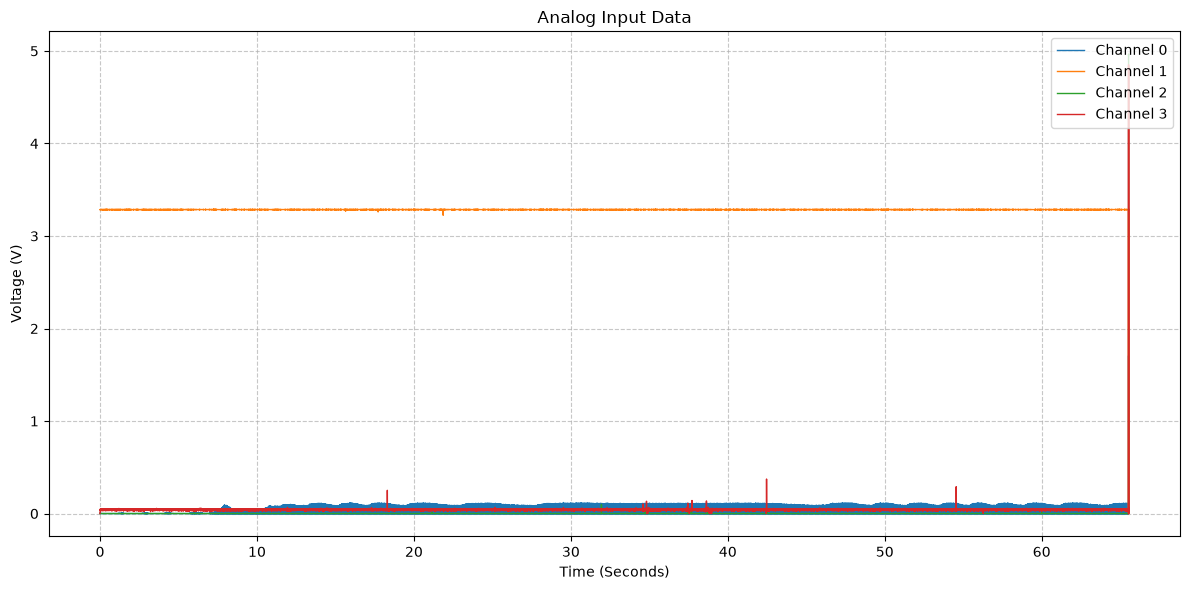

In [4]:
time_seconds, analog_volts = open_ios_analog(file_path, True)

C:\Users\gbouvier\AppData\Local\Temp\ipykernel_391428\1329881545.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


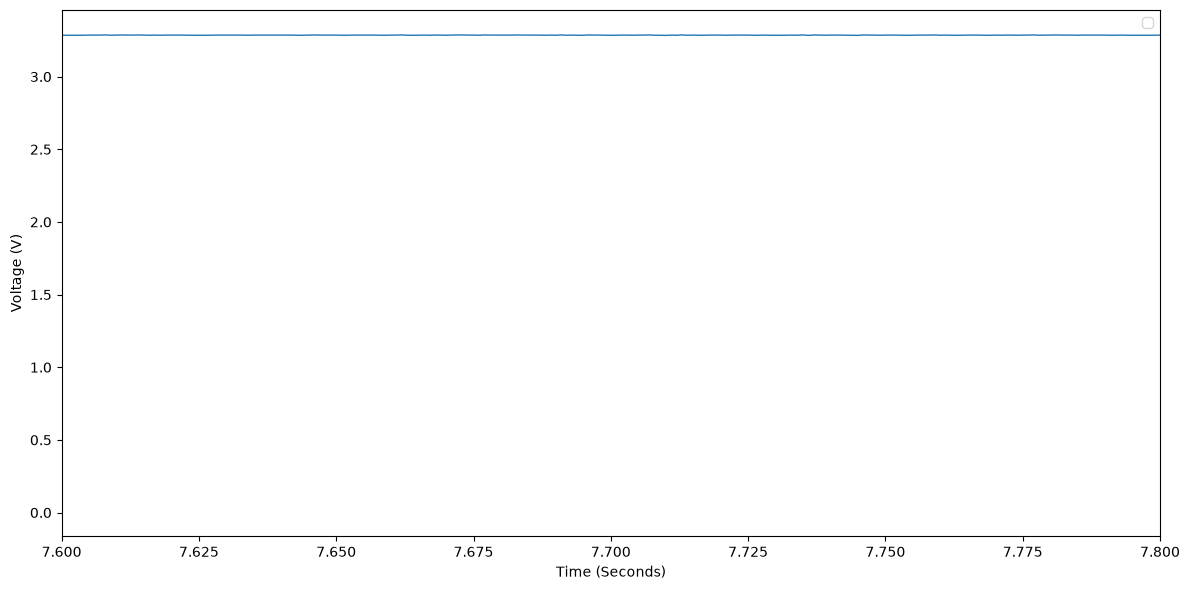

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(time_seconds, analog_volts[:, 1],  linewidth=1.0)
plt.xlabel('Time (Seconds)')
plt.ylabel('Voltage (V)')
plt.legend(loc='upper right')
plt.grid(False)
plt.xlim((7.6,7.8))
#plt.ylim((0,0.125))
plt.tight_layout()
plt.show()